In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

# Reproducibility
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Paths
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
SYNTHETIC_DIR = DATA_DIR / "synthetic"
FIGURES_DIR = PROJECT_DIR / "figures" / "03_ab_testing_uncertainty"
RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = SYNTHETIC_DIR / "microct_statistics_dataset.csv"

print("Data path:", DATA_PATH.resolve())
print("Figures directory:", FIGURES_DIR.resolve())
print("Results directory:", RESULTS_DIR.resolve())

Data path: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\data\synthetic\microct_statistics_dataset.csv
Figures directory: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\figures\03_ab_testing_uncertainty
Results directory: C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results


In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 37)


,sample_id,time_index,batch_id,protocol,is_outlier,voltage_kV,current_uA,exposure_ms,n_projections,voxel_size_um,...,cnr_drifted,pore_detectability,detectability_score,segmentation_bias,segmentation_abs_error,estimated_porosity,porosity_error,abs_porosity_error,estimated_mean_pore_diameter_um,quality_score
0,1,0,2,B_optimized,False,139.779264,79.740205,556.875111,1661,67.210426,...,11.970542,4.498315,0.817323,-0.000816,0.040911,0.028641,-0.015902,0.015902,287.169132,68.535130
1,2,1,16,B_optimized,False,133.584995,88.224429,509.266539,1568,58.500142,...,11.447199,2.712877,0.428708,-0.018846,0.058534,0.024571,-0.030900,0.030900,155.735321,60.565095
2,3,2,14,B_optimized,False,133.159816,79.573577,669.746240,1346,56.410341,...,13.206688,1.589025,0.196080,-0.026190,0.072801,0.027155,-0.021571,0.021571,77.601924,53.103840
3,4,3,9,B_optimized,False,135.628140,79.754049,671.113602,1778,53.400963,...,13.997532,3.189257,0.547174,-0.019235,0.052760,0.007369,-0.015688,0.015688,143.422889,66.903072
4,5,4,9,B_optimized,False,145.179520,75.327765,803.071348,1107,54.595544,...,9.636927,10.265431,0.999301,0.005620,0.038226,0.050214,0.003226,0.003226,546.998549,72.247540


In [3]:
print("Protocol counts:")
print(df["protocol"].value_counts())

print("\nOutlier counts:")
print(df["is_outlier"].value_counts())

print("\nColumns:")
print(df.columns.tolist())

Protocol counts:
protocol
A_standard     509
B_optimized    491
Name: count, dtype: int64

Outlier counts:
is_outlier
False    970
True      30
Name: count, dtype: int64

Columns:
['sample_id', 'time_index', 'batch_id', 'protocol', 'is_outlier', 'voltage_kV', 'current_uA', 'exposure_ms', 'n_projections', 'voxel_size_um', 'filter_thickness_mm', 'true_porosity', 'true_mean_pore_diameter_um', 'true_heterogeneity', 'sample_thickness_mm', 'mu_matrix_effective', 'intensity_matrix', 'intensity_pore', 'attenuation_contrast', 'photon_signal', 'photon_signal_norm', 'relative_noise', 'detector_drift', 'relative_noise_drifted', 'snr', 'cnr', 'snr_drifted', 'cnr_drifted', 'pore_detectability', 'detectability_score', 'segmentation_bias', 'segmentation_abs_error', 'estimated_porosity', 'porosity_error', 'abs_porosity_error', 'estimated_mean_pore_diameter_um', 'quality_score']


In [4]:
# ------------------------------------------------------------
# Metrics for A/B testing
# ------------------------------------------------------------

metrics = {
    "segmentation_abs_error": "lower_is_better",
    "abs_porosity_error": "lower_is_better",
    "quality_score": "higher_is_better",
    "snr_drifted": "higher_is_better",
    "cnr_drifted": "higher_is_better",
    "detectability_score": "higher_is_better",
}

protocol_a = "A_standard"
protocol_b = "B_optimized"

df_a = df[df["protocol"] == protocol_a].copy()
df_b = df[df["protocol"] == protocol_b].copy()

print(f"{protocol_a}: {df_a.shape[0]} rows")
print(f"{protocol_b}: {df_b.shape[0]} rows")

A_standard: 509 rows
B_optimized: 491 rows


In [5]:
# ------------------------------------------------------------
# Descriptive statistics by protocol
# ------------------------------------------------------------

summary_rows = []

for metric, direction in metrics.items():
    a_values = df_a[metric].dropna()
    b_values = df_b[metric].dropna()

    summary_rows.append({
        "metric": metric,
        "direction": direction,
        "A_mean": a_values.mean(),
        "A_std": a_values.std(),
        "A_median": a_values.median(),
        "B_mean": b_values.mean(),
        "B_std": b_values.std(),
        "B_median": b_values.median(),
        "mean_difference_B_minus_A": b_values.mean() - a_values.mean(),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.round(5)

,metric,direction,A_mean,A_std,A_median,B_mean,B_std,B_median,mean_difference_B_minus_A
0,segmentation_abs_error,lower_is_better,0.08857,0.01704,0.08926,0.05479,0.01440,0.05266,-0.03377
1,abs_porosity_error,lower_is_better,0.01581,0.01179,0.01348,0.01281,0.01058,0.01009,-0.00300
2,quality_score,higher_is_better,37.58634,9.05737,36.93825,60.04448,11.27943,61.58387,22.45815
3,snr_drifted,higher_is_better,1.41527,0.45765,1.36554,2.96292,0.88465,2.88689,1.54764
4,cnr_drifted,higher_is_better,5.63220,1.07718,5.53926,10.83784,1.97803,10.76923,5.20564
5,detectability_score,higher_is_better,0.47426,0.25285,0.41974,0.68189,0.24990,0.72184,0.20763


In [6]:
# ------------------------------------------------------------
# Statistical tests for A/B comparison
# ------------------------------------------------------------

def cohens_d(x, y):
    """
    Cohen's d for two independent samples.
    Positive values mean y has a larger mean than x.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1))
        / (nx + ny - 2)
    )

    return (np.mean(y) - np.mean(x)) / pooled_std


test_rows = []

for metric, direction in metrics.items():
    a_values = df_a[metric].dropna().values
    b_values = df_b[metric].dropna().values

    mean_a = np.mean(a_values)
    mean_b = np.mean(b_values)
    diff_b_minus_a = mean_b - mean_a

    # Welch t-test
    t_stat, t_pvalue = stats.ttest_ind(
        b_values,
        a_values,
        equal_var=False
    )

    # Mann-Whitney U test
    u_stat, u_pvalue = stats.mannwhitneyu(
        b_values,
        a_values,
        alternative="two-sided"
    )

    effect_size = cohens_d(a_values, b_values)

    if direction == "higher_is_better":
        improvement = diff_b_minus_a > 0
    else:
        improvement = diff_b_minus_a < 0

    test_rows.append({
        "metric": metric,
        "direction": direction,
        "A_mean": mean_a,
        "B_mean": mean_b,
        "difference_B_minus_A": diff_b_minus_a,
        "B_improves": improvement,
        "welch_t_stat": t_stat,
        "welch_p_value": t_pvalue,
        "mannwhitney_u_stat": u_stat,
        "mannwhitney_p_value": u_pvalue,
        "cohens_d": effect_size,
        "abs_cohens_d": abs(effect_size),
    })

tests_df = pd.DataFrame(test_rows)

tests_df.round(6)

,metric,direction,A_mean,B_mean,difference_B_minus_A,B_improves,welch_t_stat,welch_p_value,mannwhitney_u_stat,mannwhitney_p_value,cohens_d,abs_cohens_d
0,segmentation_abs_error,lower_is_better,0.088566,0.054794,-0.033772,True,-33.896582,0.000000,16486.0,0.00000,-2.137722,2.137722
1,abs_porosity_error,lower_is_better,0.015812,0.012809,-0.003003,True,-4.242127,0.000024,104820.0,0.00001,-0.267815,0.267815
2,quality_score,higher_is_better,37.586336,60.044485,22.458148,True,34.641878,0.000000,232943.0,0.00000,2.199843,2.199843
3,snr_drifted,higher_is_better,1.415275,2.962918,1.547643,True,34.559814,0.000000,238576.0,0.00000,2.208986,2.208986
4,cnr_drifted,higher_is_better,5.632199,10.837835,5.205637,True,51.422045,0.000000,245180.0,0.00000,3.284697,3.284697
5,detectability_score,higher_is_better,0.474261,0.681893,0.207632,True,13.059075,0.000000,180199.0,0.00000,0.825888,0.825888


In [9]:
# ------------------------------------------------------------
# Bootstrap confidence intervals for mean differences
# ------------------------------------------------------------

def bootstrap_mean_difference(a_values, b_values, n_bootstrap=10000, confidence=0.95):
    """
    Bootstrap confidence interval for the mean difference B - A.
    """
    a_values = np.asarray(a_values)
    b_values = np.asarray(b_values)

    bootstrap_diffs = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        a_sample = rng.choice(a_values, size=len(a_values), replace=True)
        b_sample = rng.choice(b_values, size=len(b_values), replace=True)
        bootstrap_diffs[i] = np.mean(b_sample) - np.mean(a_sample)

    alpha = 1 - confidence
    lower = np.percentile(bootstrap_diffs, 100 * alpha / 2)
    upper = np.percentile(bootstrap_diffs, 100 * (1 - alpha / 2))

    return bootstrap_diffs, lower, upper


bootstrap_rows = []
bootstrap_distributions = {}

for metric, direction in metrics.items():
    a_values = df_a[metric].dropna().values
    b_values = df_b[metric].dropna().values

    bootstrap_diffs, ci_lower, ci_upper = bootstrap_mean_difference(
        a_values,
        b_values,
        n_bootstrap=10000,
        confidence=0.95
    )

    observed_diff = np.mean(b_values) - np.mean(a_values)

    bootstrap_distributions[metric] = bootstrap_diffs

    if direction == "higher_is_better":
        improvement_supported = ci_lower > 0
    else:
        improvement_supported = ci_upper < 0

    bootstrap_rows.append({
        "metric": metric,
        "direction": direction,
        "observed_difference_B_minus_A": observed_diff,
        "bootstrap_ci_95_lower": ci_lower,
        "bootstrap_ci_95_upper": ci_upper,
        "improvement_supported_by_ci": improvement_supported,
    })

bootstrap_df = pd.DataFrame(bootstrap_rows)

bootstrap_df.round(6)

,metric,direction,observed_difference_B_minus_A,bootstrap_ci_95_lower,bootstrap_ci_95_upper,improvement_supported_by_ci
0,segmentation_abs_error,lower_is_better,-0.033772,-0.035728,-0.031833,True
1,abs_porosity_error,lower_is_better,-0.003003,-0.004401,-0.001625,True
2,quality_score,higher_is_better,22.458148,21.148456,23.715246,True
3,snr_drifted,higher_is_better,1.547643,1.460310,1.636107,True
4,cnr_drifted,higher_is_better,5.205637,5.002877,5.404704,True
5,detectability_score,higher_is_better,0.207632,0.176299,0.237827,True


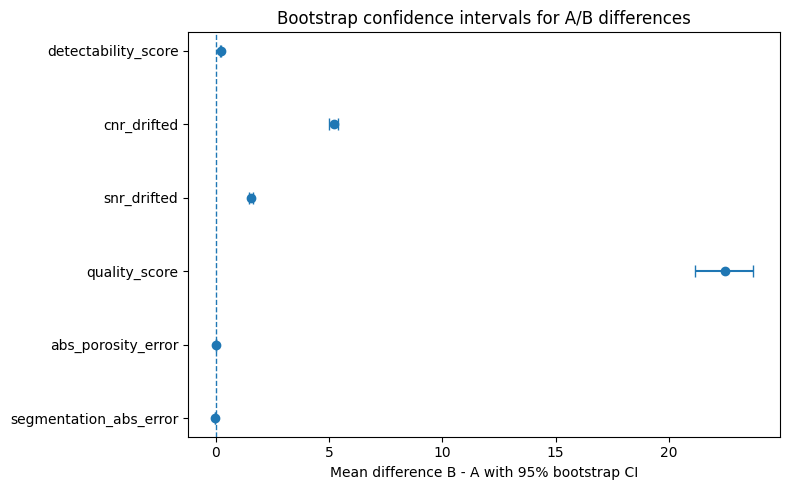

In [10]:
# ------------------------------------------------------------
# Plot bootstrap confidence intervals for B - A differences
# ------------------------------------------------------------

plot_df = bootstrap_df.copy()

# Sort metrics for a cleaner visual order
metric_order = [
    "segmentation_abs_error",
    "abs_porosity_error",
    "quality_score",
    "snr_drifted",
    "cnr_drifted",
    "detectability_score",
]

plot_df["metric"] = pd.Categorical(
    plot_df["metric"],
    categories=metric_order,
    ordered=True
)

plot_df = plot_df.sort_values("metric")

y_positions = np.arange(len(plot_df))

x_values = plot_df["observed_difference_B_minus_A"].values
xerr_lower = x_values - plot_df["bootstrap_ci_95_lower"].values
xerr_upper = plot_df["bootstrap_ci_95_upper"].values - x_values

plt.figure(figsize=(8, 5))
plt.errorbar(
    x_values,
    y_positions,
    xerr=[xerr_lower, xerr_upper],
    fmt="o",
    capsize=4
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.yticks(y_positions, plot_df["metric"])
plt.xlabel("Mean difference B - A with 95% bootstrap CI")
plt.title("Bootstrap confidence intervals for A/B differences")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "bootstrap_ci_ab_differences.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

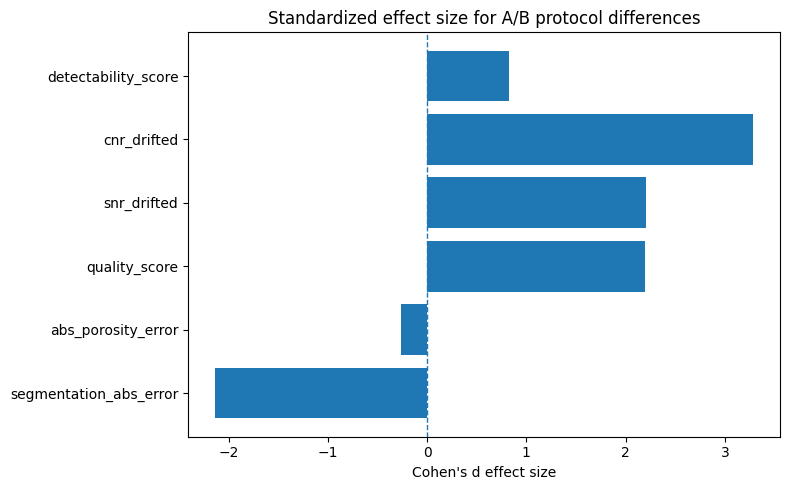

,metric,direction,difference_B_minus_A,cohens_d,abs_cohens_d,B_improves
0,segmentation_abs_error,lower_is_better,-0.0338,-2.1377,2.1377,True
1,abs_porosity_error,lower_is_better,-0.0030,-0.2678,0.2678,True
2,quality_score,higher_is_better,22.4581,2.1998,2.1998,True
3,snr_drifted,higher_is_better,1.5476,2.2090,2.2090,True
4,cnr_drifted,higher_is_better,5.2056,3.2847,3.2847,True
5,detectability_score,higher_is_better,0.2076,0.8259,0.8259,True


In [11]:
# ------------------------------------------------------------
# Plot standardized effect sizes
# ------------------------------------------------------------

effect_df = tests_df.copy()

metric_order = [
    "segmentation_abs_error",
    "abs_porosity_error",
    "quality_score",
    "snr_drifted",
    "cnr_drifted",
    "detectability_score",
]

effect_df["metric"] = pd.Categorical(
    effect_df["metric"],
    categories=metric_order,
    ordered=True
)

effect_df = effect_df.sort_values("metric")

y_positions = np.arange(len(effect_df))

plt.figure(figsize=(8, 5))
plt.barh(
    y_positions,
    effect_df["cohens_d"]
)

plt.axvline(0, linestyle="--", linewidth=1)
plt.yticks(y_positions, effect_df["metric"])
plt.xlabel("Cohen's d effect size")
plt.title("Standardized effect size for A/B protocol differences")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "cohens_d_effect_sizes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

effect_df[[
    "metric",
    "direction",
    "difference_B_minus_A",
    "cohens_d",
    "abs_cohens_d",
    "B_improves"
]].round(4)

In [12]:
# ------------------------------------------------------------
# Save A/B testing results
# ------------------------------------------------------------

summary_path = RESULTS_DIR / "03_ab_protocol_descriptive_summary.csv"
tests_path = RESULTS_DIR / "03_ab_protocol_statistical_tests.csv"
bootstrap_path = RESULTS_DIR / "03_ab_protocol_bootstrap_confidence_intervals.csv"
effect_size_path = RESULTS_DIR / "03_ab_protocol_effect_sizes.csv"

summary_df.to_csv(summary_path, index=False)
tests_df.to_csv(tests_path, index=False)
bootstrap_df.to_csv(bootstrap_path, index=False)
effect_df.to_csv(effect_size_path, index=False)

print("Saved:")
print(summary_path.resolve())
print(tests_path.resolve())
print(bootstrap_path.resolve())
print(effect_size_path.resolve())

Saved:
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\03_ab_protocol_descriptive_summary.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\03_ab_protocol_statistical_tests.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\03_ab_protocol_bootstrap_confidence_intervals.csv
C:\Users\Peter\ai-imaging-portfolio\projects\04_applied_statistics_for_scientific_imaging\results\03_ab_protocol_effect_sizes.csv


In [13]:
# ------------------------------------------------------------
# Notebook completion summary
# ------------------------------------------------------------

print("A/B testing and uncertainty analysis completed.")
print()
print("Compared protocols:")
print(f"- A: {protocol_a}")
print(f"- B: {protocol_b}")
print()
print("Metrics evaluated:")
for metric, direction in metrics.items():
    print(f"- {metric} ({direction})")
print()
print("Main statistical outputs:")
print("- Descriptive statistics by protocol")
print("- Welch t-test")
print("- Mann-Whitney U test")
print("- Cohen's d effect size")
print("- Bootstrap 95% confidence intervals")
print()
print("Main conclusion:")
print("B_optimized improves all evaluated metrics relative to A_standard.")

A/B testing and uncertainty analysis completed.

Compared protocols:
- A: A_standard
- B: B_optimized

Metrics evaluated:
- segmentation_abs_error (lower_is_better)
- abs_porosity_error (lower_is_better)
- quality_score (higher_is_better)
- snr_drifted (higher_is_better)
- cnr_drifted (higher_is_better)
- detectability_score (higher_is_better)

Main statistical outputs:
- Descriptive statistics by protocol
- Welch t-test
- Mann-Whitney U test
- Cohen's d effect size
- Bootstrap 95% confidence intervals

Main conclusion:
B_optimized improves all evaluated metrics relative to A_standard.
